In [1]:
!pip install pandas numpy scikit-learn xgboost lightgbm scipy matplotlib seaborn

  Using cached pandas-3.0.3-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.4.6-cp313-cp313-win_amd64.whl.metadata (6.6 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp313-cp313-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp313-cp313-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached pandas-3.0.3-cp313-cp313-win_amd64.whl (9.8 MB)
Using cached numpy-2.4.6-cp313-cp313-win_amd64.whl (12.3 MB)
   --------------------------------------

### Group 9 - Malayo Ang Lipad, Mababaw Ang Pundasyon: Philippine Export Vulnerability and Trade Potential Analysis Using Machine Learning and Anomaly Detection 


##### 1. Growth & Efficiency


Improving Export Efficiency (Unit Value Analysis)

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.cluster import KMeans

# 1. Load Data
df = pd.read_csv('combined.csv')

# 2. Strict Filtering
# Guard against zero/null/negative Quantity and FOB
initial_len = len(df)
df = df[(df['Quantity'] > 0) & (df['FOB'] > 0)].copy()
df.dropna(subset=['Quantity', 'FOB', 'Year', 'Commodity', 'Country Of Destination'], inplace=True)
print(f"Removed {initial_len - len(df)} rows due to zero, negative, or missing values.")

# 3. Create Targets
df['Unit Value'] = df['FOB'] / df['Quantity']
df['Log Unit Value'] = np.log1p(df['Unit Value'])

print("Data Preprocessing Complete. First 5 rows:")
display(df.head())

Removed 9 rows due to zero, negative, or missing values.
Data Preprocessing Complete. First 5 rows:


,Commodity,Country Of Destination,Year,Quantity,FOB,source_file,Unit Value,Log Unit Value
0,Abaca Fibers,Bangladesh,2020,180.00,49500.0,PhilippineExports(2020-2021).csv,275.000000,5.620401
1,Abaca Fibers,Bangladesh,2022,11226.86,27900.0,PhilippineExports(2022-2023).csv,2.485112,1.248500
2,Abaca Fibers,Bangladesh,2024,33750.00,83250.0,PhilippineExports(2024-2025).csv,2.466667,1.243194
3,Abaca Fibers,Egypt Arab Republic,2018,720.00,191880.0,PhilippineExports(2018-2019).csv,266.500000,5.589120
4,Abaca Fibers,Egypt Arab Republic,2019,360.00,85320.0,PhilippineExports(2018-2019).csv,237.000000,5.472271


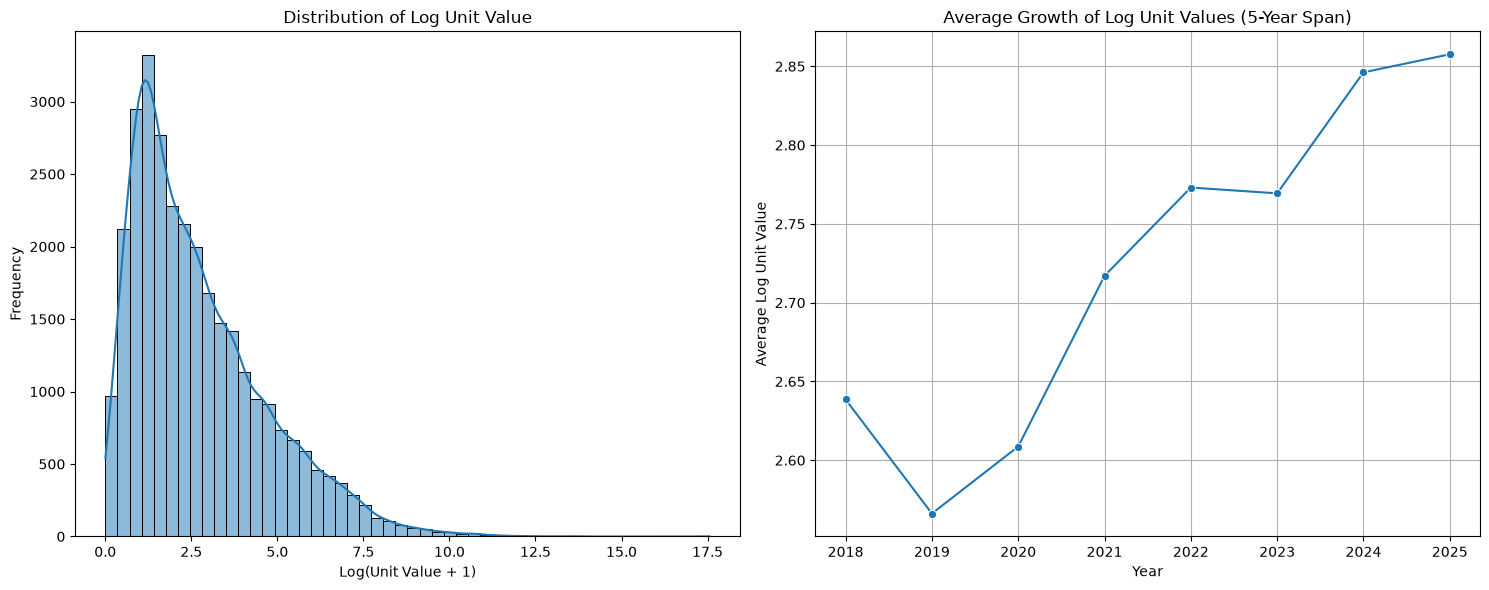

In [13]:
# --- EDA Layer: Plot the distribution and average growth of log unit values ---
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['Log Unit Value'], bins=50, kde=True)
plt.title('Distribution of Log Unit Value')
plt.xlabel('Log(Unit Value + 1)')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
avg_log_uv = df.groupby('Year')['Log Unit Value'].mean().reset_index()
sns.lineplot(data=avg_log_uv, x='Year', y='Log Unit Value', marker='o')
plt.title('Average Growth of Log Unit Values (5-Year Span)')
plt.xlabel('Year')
plt.ylabel('Average Log Unit Value')
plt.xticks(avg_log_uv['Year'].astype(int))
plt.grid(True)

plt.tight_layout()
plt.show()

XGBoost Results:
  Train R2: 0.6824 | Train MSE: 1.1916
  Test R2:  0.5935 | Test MSE:  1.5945

Linear Regression Results:
  Train R2: 0.1865 | Train MSE: 3.0525
  Test R2:  0.1837 | Test MSE:  3.2019


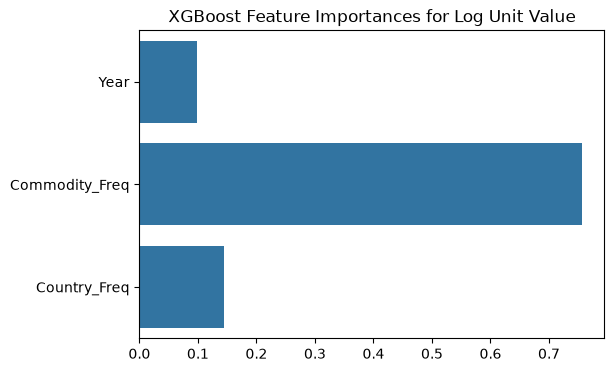

In [14]:
# --- Unit Value Modeling (Linear Regression vs XGBoost) ---

# Prepare Features and Target
X = df[['Year', 'Commodity', 'Country Of Destination']].copy()
y = df['Log Unit Value']

# Train/Test Split (80/20)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Feature Engineering for XGBoost (Frequency Encoding) ---
freq_commodity = X_train_raw['Commodity'].value_counts(normalize=True)
freq_country = X_train_raw['Country Of Destination'].value_counts(normalize=True)

X_train_xgb = X_train_raw.copy()
X_test_xgb = X_test_raw.copy()

X_train_xgb['Commodity_Freq'] = X_train_xgb['Commodity'].map(freq_commodity).fillna(0)
X_train_xgb['Country_Freq'] = X_train_xgb['Country Of Destination'].map(freq_country).fillna(0)
X_test_xgb['Commodity_Freq'] = X_test_xgb['Commodity'].map(freq_commodity).fillna(0)
X_test_xgb['Country_Freq'] = X_test_xgb['Country Of Destination'].map(freq_country).fillna(0)

features_xgb = ['Year', 'Commodity_Freq', 'Country_Freq']

# Train XGBoost
xgb_model = XGBRegressor(random_state=42, n_estimators=100, max_depth=6)
xgb_model.fit(X_train_xgb[features_xgb], y_train)

y_pred_train_xgb = xgb_model.predict(X_train_xgb[features_xgb])
y_pred_test_xgb = xgb_model.predict(X_test_xgb[features_xgb])

# --- Feature Engineering for Linear Regression (One-Hot Encoding top 10) ---
top_10_commodities = X_train_raw['Commodity'].value_counts().nlargest(10).index
top_10_countries = X_train_raw['Country Of Destination'].value_counts().nlargest(10).index

X_train_lr = X_train_raw.copy()
X_test_lr = X_test_raw.copy()

X_train_lr['Commodity_Group'] = X_train_lr['Commodity'].apply(lambda x: x if x in top_10_commodities else 'Other')
X_train_lr['Country_Group'] = X_train_lr['Country Of Destination'].apply(lambda x: x if x in top_10_countries else 'Other')
X_test_lr['Commodity_Group'] = X_test_lr['Commodity'].apply(lambda x: x if x in top_10_commodities else 'Other')
X_test_lr['Country_Group'] = X_test_lr['Country Of Destination'].apply(lambda x: x if x in top_10_countries else 'Other')

# One-hot encode dropping the first category to avoid dummy variable trap
X_train_lr_encoded = pd.get_dummies(X_train_lr[['Year', 'Commodity_Group', 'Country_Group']], drop_first=True)
# Ensure test set has same columns
X_test_lr_encoded = pd.get_dummies(X_test_lr[['Year', 'Commodity_Group', 'Country_Group']], drop_first=True)
X_test_lr_encoded = X_test_lr_encoded.reindex(columns=X_train_lr_encoded.columns, fill_value=0)

# Train Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_lr_encoded, y_train)

y_pred_train_lr = lr_model.predict(X_train_lr_encoded)
y_pred_test_lr = lr_model.predict(X_test_lr_encoded)

# --- Reporting Results ---
print("XGBoost Results:")
print(f"  Train R2: {r2_score(y_train, y_pred_train_xgb):.4f} | Train MSE: {mean_squared_error(y_train, y_pred_train_xgb):.4f}")
print(f"  Test R2:  {r2_score(y_test, y_pred_test_xgb):.4f} | Test MSE:  {mean_squared_error(y_test, y_pred_test_xgb):.4f}")

print("\nLinear Regression Results:")
print(f"  Train R2: {r2_score(y_train, y_pred_train_lr):.4f} | Train MSE: {mean_squared_error(y_train, y_pred_train_lr):.4f}")
print(f"  Test R2:  {r2_score(y_test, y_pred_test_lr):.4f} | Test MSE:  {mean_squared_error(y_test, y_pred_test_lr):.4f}")

# Plot XGBoost Feature Importances
plt.figure(figsize=(6, 4))
importances = xgb_model.feature_importances_
sns.barplot(x=importances, y=features_xgb)
plt.title('XGBoost Feature Importances for Log Unit Value')
plt.show()

##### 2. Strengths & Vulnerabilities



High Market Concentration

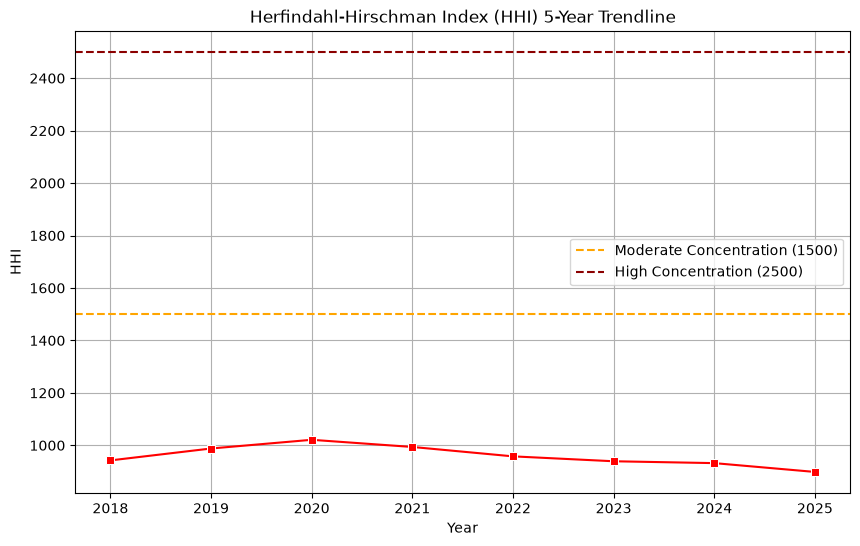

In [29]:
# --- High Market Concentration: HHI Index ---

# 1. Clean numeric columns in case FOB/Quantity were read as strings (e.g. "1,234.56")
df['FOB'] = pd.to_numeric(
    df['FOB'].astype(str).str.replace(',', '').str.strip(),
    errors='coerce'
)
df['Quantity'] = pd.to_numeric(
    df['Quantity'].astype(str).str.replace(',', '').str.strip(),
    errors='coerce'
)

# 2. Clean Year (drop rows where Year is missing/non-numeric)
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df = df.dropna(subset=['Year'])
df['Year'] = df['Year'].astype(int)

# 3. Standardize country names to avoid duplicate-but-different-spelling entries
df['Country Of Destination'] = df['Country Of Destination'].astype(str).str.strip().str.upper()

# 4. Drop rows with missing/invalid FOB before aggregating
df_hhi = df.dropna(subset=['FOB'])
df_hhi = df_hhi[df_hhi['FOB'] > 0]

# --- HHI calculation ---
yearly_totals = df_hhi.groupby('Year')['FOB'].sum().reset_index().rename(columns={'FOB': 'Total Yearly FOB'})
country_yearly = df_hhi.groupby(['Year', 'Country Of Destination'])['FOB'].sum().reset_index()

country_yearly = pd.merge(country_yearly, yearly_totals, on='Year')
country_yearly['Market Share (%)'] = (country_yearly['FOB'] / country_yearly['Total Yearly FOB']) * 100
country_yearly['Share Squared'] = country_yearly['Market Share (%)'] ** 2

hhi_per_year = country_yearly.groupby('Year')['Share Squared'].sum().reset_index().rename(columns={'Share Squared': 'HHI'})

plt.figure(figsize=(10, 6))
sns.lineplot(data=hhi_per_year, x='Year', y='HHI', marker='s', color='red')
plt.title('Herfindahl-Hirschman Index (HHI) 5-Year Trendline')
plt.xlabel('Year')
plt.ylabel('HHI')
plt.axhline(y=1500, color='orange', linestyle='--', label='Moderate Concentration (1500)')
plt.axhline(y=2500, color='darkred', linestyle='--', label='High Concentration (2500)')
plt.xticks(hhi_per_year['Year'].astype(int))
plt.legend()
plt.grid(True)
plt.show()

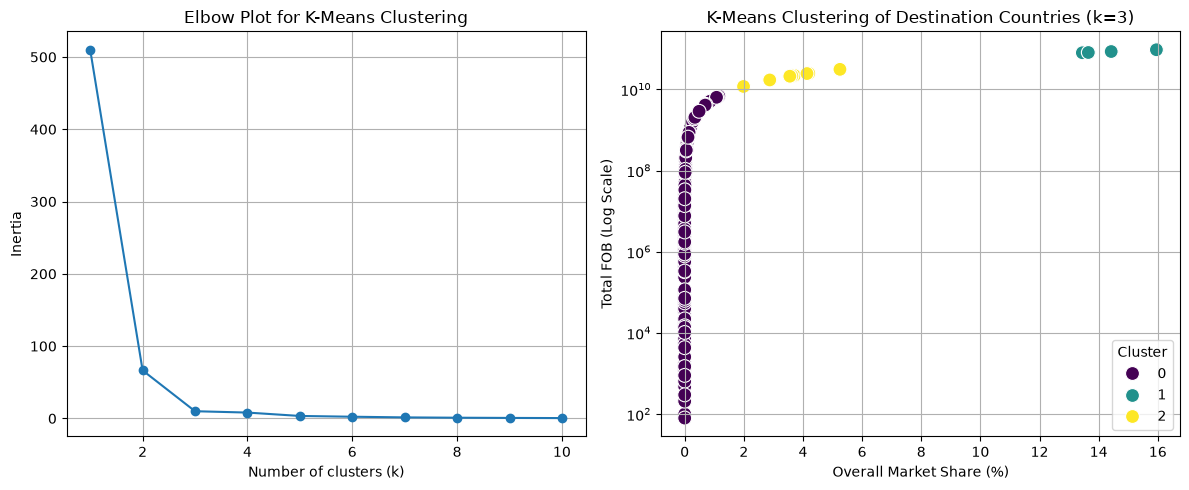

Top 5 Countries and their Clusters:


,Country Of Destination,Total_FOB,Overall Market Share (%),Cluster
240,UNITED STATES OF AMERICA,9.429203e+10,15.952448,1
112,JAPAN,8.525280e+10,14.423179,1
175,PEOPLE'S REPUBLIC OF CHINA,8.068268e+10,13.650002,1
101,"HONG KONG, CHINA",7.948848e+10,13.447966,1
198,SINGAPORE,3.103411e+10,5.250392,2


In [30]:
# --- High Market Concentration: K-Means Clustering ---

# Aggregate across the entire time span to cluster countries by their overall reliance
country_agg = df.groupby('Country Of Destination').agg(
    Total_FOB=('FOB', 'sum')
).reset_index()

total_fob_all = country_agg['Total_FOB'].sum()
country_agg['Overall Market Share (%)'] = (country_agg['Total_FOB'] / total_fob_all) * 100

# Prepare data for clustering
X_cluster = country_agg[['Total_FOB', 'Overall Market Share (%)']].copy()

# Critical: Scale the data so FOB (millions) doesn't dominate Market Share (0-100)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# 1. Elbow Plot to justify k
inertias = []
k_range = range(1, 11)
for k in k_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans_temp.fit(X_scaled)
    inertias.append(kmeans_temp.inertia_)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(k_range, inertias, marker='o')
plt.title('Elbow Plot for K-Means Clustering')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)

# 2. Fit final K-Means with k=3 based on assumed/justified elbow
k_optimal = 3
kmeans_final = KMeans(n_clusters=k_optimal, random_state=42, n_init='auto')
country_agg['Cluster'] = kmeans_final.fit_predict(X_scaled)

plt.subplot(1, 2, 2)
sns.scatterplot(
    data=country_agg,
    x='Overall Market Share (%)',
    y='Total_FOB',
    hue='Cluster',
    palette='viridis',
    s=100
)
plt.yscale('log') # Log scale for better visibility of heavily right-skewed FOB
plt.title(f'K-Means Clustering of Destination Countries (k={k_optimal})')
plt.xlabel('Overall Market Share (%)')
plt.ylabel('Total FOB (Log Scale)')
plt.legend(title='Cluster')
plt.grid(True)

plt.tight_layout()
plt.show()

print("Top 5 Countries and their Clusters:")
display(country_agg.sort_values(by='Total_FOB', ascending=False).head())

Current Commodity Danger

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest

# ---- CONFIG -----------------------------------------------------------------
INPUT_CSV = "combined.csv"        # <-- path to your combined CSV
PRE_PANDEMIC_CUTOFF = 2020        # years < this = "pre-pandemic"
N_CURRENT_YEARS = 1               # how many of the most recent years = "current"
CONTAMINATION = 0.15              # expected proportion of "in danger" commodities
RANDOM_STATE = 42
TOP_N = 10                        # how many commodities to show in the bar chart

# ---- 1. LOAD ------------------------------------------------------------
df = pd.read_csv(INPUT_CSV)
df["Year"] = df["Year"].astype(int)
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
df["FOB"] = pd.to_numeric(df["FOB"], errors="coerce")

df.head()

,Commodity,Country Of Destination,Year,Quantity,FOB,source_file
0,Abaca Fibers,Bangladesh,2020,180.00,49500.0,PhilippineExports(2020-2021).csv
1,Abaca Fibers,Bangladesh,2022,11226.86,27900.0,PhilippineExports(2022-2023).csv
2,Abaca Fibers,Bangladesh,2024,33750.00,83250.0,PhilippineExports(2024-2025).csv
3,Abaca Fibers,Egypt Arab Republic,2018,720.00,191880.0,PhilippineExports(2018-2019).csv
4,Abaca Fibers,Egypt Arab Republic,2019,360.00,85320.0,PhilippineExports(2018-2019).csv


In [ ]:
# =============================================================================
# EDA — Structural Checks
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("combined.csv")
df["Year"] = df["Year"].astype(int)
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
df["FOB"] = pd.to_numeric(df["FOB"], errors="coerce")

print("Shape:", df.shape)
print("\nDtypes / non-null counts:")
df.info()

print("\nRows per year:")
print(df["Year"].value_counts().sort_index())

print("\nDuplicate (Commodity, Country, Year) rows:",
      df.duplicated(subset=["Commodity", "Country Of Destination", "Year"]).sum())

print("\nUnique commodities:", df["Commodity"].nunique())
print("Unique countries:", df["Country Of Destination"].nunique())

print("\nYears of data available per commodity (min/max/median):")
years_per_commodity = df.groupby("Commodity")["Year"].nunique()
print(years_per_commodity.describe()[["min", "50%", "max"]])

print("\nCommodities with pre-2020 data:",
      df.loc[df["Year"] < 2020, "Commodity"].nunique(), "of", df["Commodity"].nunique())

Shape: (30444, 6)

Dtypes / non-null counts:
<class 'pandas.DataFrame'>
RangeIndex: 30444 entries, 0 to 30443
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Commodity               30444 non-null  str    
 1   Country Of Destination  30444 non-null  str    
 2   Year                    30444 non-null  int64  
 3   Quantity                30444 non-null  float64
 4   FOB                     30444 non-null  float64
 5   source_file             30444 non-null  str    
dtypes: float64(2), int64(1), str(3)
memory usage: 1.4 MB

Rows per year:
Year
2018    4055
2019    3888
2020    3722
2021    3815
2022    3721
2023    3687
2024    3684
2025    3872
Name: count, dtype: int64

Duplicate (Commodity, Country, Year) rows: 0

Unique commodities: 73
Unique countries: 255

Years of data available per commodity (min/max/median):
min    1.0
50%    8.0
max    8.0
Name: Year, dtype: float64

Commodities wit

Summary statistics:
           Quantity           FOB
count  3.044400e+04  3.044400e+04
mean   1.932629e+07  1.941538e+07
std    6.909233e+08  1.894973e+08
min    0.000000e+00  2.500000e+01
25%    6.926000e+02  1.333925e+04
50%    1.749248e+04  1.357595e+05
75%    2.324217e+05  1.585202e+06
max    5.153830e+10  9.189868e+09

Zero or negative values (likely data issues, not real anomalies):
Quantity <= 0: 9
FOB <= 0: 0

Top 5 largest FOB rows (sanity-check for entry errors):
                                              Commodity  \
7706  Electronic Products_Components/Devices (Semico...   
7703  Electronic Products_Components/Devices (Semico...   
7702  Electronic Products_Components/Devices (Semico...   
7701  Electronic Products_Components/Devices (Semico...   
7705  Electronic Products_Components/Devices (Semico...   

     Country Of Destination  Year      Quantity           FOB  
7706       Hong Kong, China  2025  2.523581e+09  9.189868e+09  
7703       Hong Kong, China  2022  1.4

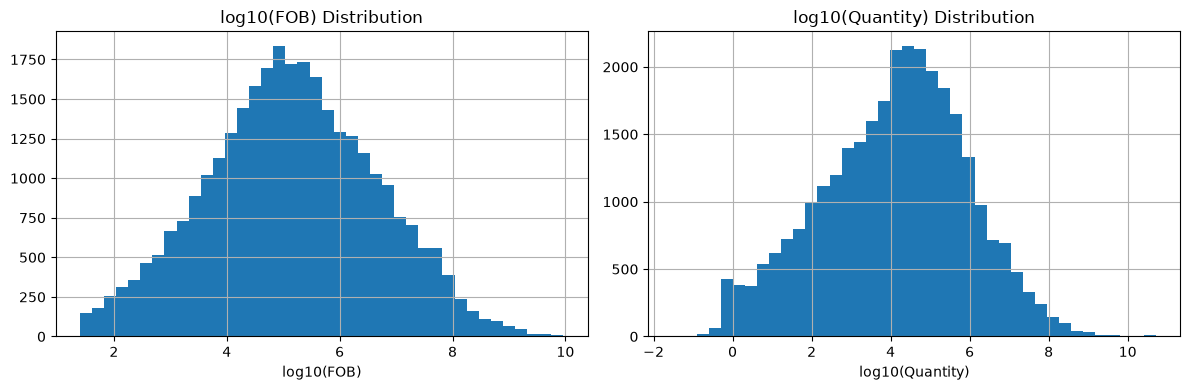

In [ ]:
# =============================================================================
# EDA — Distribution Checks
# =============================================================================
print("Summary statistics:")
print(df[["Quantity", "FOB"]].describe())

print("\nZero or negative values (likely data issues, not real anomalies):")
print("Quantity <= 0:", (df["Quantity"] <= 0).sum())
print("FOB <= 0:", (df["FOB"] <= 0).sum())

print("\nTop 5 largest FOB rows (sanity-check for entry errors):")
print(df.nlargest(5, "FOB")[["Commodity", "Country Of Destination", "Year", "Quantity", "FOB"]])

print("\nTop 5 largest Quantity rows:")
print(df.nlargest(5, "Quantity")[["Commodity", "Country Of Destination", "Year", "Quantity", "FOB"]])

# Distributions — log scale, since trade data is typically heavy-tailed
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df.loc[df["FOB"] > 0, "FOB"].apply(np.log10).hist(bins=40, ax=axes[0])
axes[0].set_title("log10(FOB) Distribution")
axes[0].set_xlabel("log10(FOB)")

df.loc[df["Quantity"] > 0, "Quantity"].apply(np.log10).hist(bins=40, ax=axes[1])
axes[1].set_title("log10(Quantity) Distribution")
axes[1].set_xlabel("log10(Quantity)")

plt.tight_layout()
plt.show()

In [ ]:
# ---- 2. PREPROCESS / FEATURE ENGINEERING --------------------------------
# Aggregate country-level rows into one row per Commodity-Year
yearly = (
    df.groupby(["Commodity", "Year"], as_index=False)[["Quantity", "FOB"]]
    .sum()
)

last_year = yearly["Year"].max()
current_years = list(range(last_year - N_CURRENT_YEARS + 1, last_year + 1))
pre_years = sorted(y for y in yearly["Year"].unique() if y < PRE_PANDEMIC_CUTOFF)

if not pre_years:
    raise ValueError(
        f"No years before {PRE_PANDEMIC_CUTOFF} found in the data — "
        "can't compute a pre-pandemic baseline."
    )

baseline = (
    yearly[yearly["Year"].isin(pre_years)]
    .groupby("Commodity", as_index=False)[["Quantity", "FOB"]]
    .mean()
    .rename(columns={"Quantity": "baseline_qty", "FOB": "baseline_fob"})
)
current = (
    yearly[yearly["Year"].isin(current_years)]
    .groupby("Commodity", as_index=False)[["Quantity", "FOB"]]
    .mean()
    .rename(columns={"Quantity": "current_qty", "FOB": "current_fob"})
)

feat = baseline.merge(current, on="Commodity", how="inner")

# Drop commodities with a ~zero baseline — % change is meaningless/explodes
feat = feat[feat["baseline_fob"] > 0].copy()

# Core "danger" signals: % change from pre-pandemic baseline
feat["pct_change_fob"] = (feat["current_fob"] - feat["baseline_fob"]) / feat["baseline_fob"]
feat["pct_change_qty"] = (feat["current_qty"] - feat["baseline_qty"]) / feat["baseline_qty"]

# Volatility: how much this commodity bounces around year to year
yoy = yearly.sort_values(["Commodity", "Year"]).copy()
yoy["fob_pct_change_yoy"] = yoy.groupby("Commodity")["FOB"].pct_change()
volatility = (
    yoy.groupby("Commodity")["fob_pct_change_yoy"]
    .std()
    .rename("volatility")
    .reset_index()
)
feat = feat.merge(volatility, on="Commodity", how="left")
feat["volatility"] = feat["volatility"].fillna(0)

# Scale of the commodity (context for plotting, not fed to the model)
feat["baseline_fob_share"] = feat["baseline_fob"] / feat["baseline_fob"].sum()

# Clean up any remaining inf/NaN
feat = feat.replace([np.inf, -np.inf], np.nan)
feat = feat.dropna(subset=["pct_change_fob", "pct_change_qty", "volatility"])
feat = feat.reset_index(drop=True)

print(f"{len(feat)} commodities with usable pre-pandemic baselines")
feat.head()

65 commodities with usable pre-pandemic baselines


,Commodity,baseline_qty,baseline_fob,current_qty,current_fob,pct_change_fob,pct_change_qty,volatility,baseline_fob_share
0,Abaca Fibers,1.241920e+05,3.017251e+07,1.252361e+07,2.172388e+07,-0.280011,99.840714,0.239150,0.000431
1,Activated Carbon,7.471295e+07,1.298517e+08,6.994068e+07,1.538772e+08,0.185022,-0.063875,0.201407,0.001854
2,Articles Of Apparel,2.948637e+08,9.510190e+08,8.737448e+07,6.888137e+08,-0.275710,-0.703678,0.162505,0.013581
3,"Baby Carriage, Toys, Games, And Sporting Goods",3.093406e+07,1.778717e+08,2.681055e+07,1.923818e+08,0.081576,-0.133300,0.153893,0.002540
4,Bananas (Fresh),3.764850e+09,1.667971e+09,3.041503e+09,1.681935e+09,0.008372,-0.192132,0.261030,0.023819


In [ ]:
# ---- 3. ISOLATION FOREST -------------------------------------------------
model_cols = ["pct_change_fob", "pct_change_qty", "volatility"]
X = feat[model_cols].values

model = IsolationForest(
    n_estimators=300,
    contamination=CONTAMINATION,
    random_state=RANDOM_STATE,
)
feat["anomaly_flag"] = model.fit_predict(X)       # -1 = anomaly, 1 = normal
feat["danger_score"] = -model.score_samples(X)    # higher = more anomalous/dangerous
feat["in_danger"] = feat["anomaly_flag"] == -1

result = feat.sort_values("danger_score", ascending=False).reset_index(drop=True)

n_danger = result["in_danger"].sum()
print(f"{n_danger} commodities flagged as 'in danger':\n")
result.loc[result["in_danger"],
            ["Commodity", "pct_change_fob", "pct_change_qty", "volatility", "danger_score"]]

10 commodities flagged as 'in danger':



,Commodity,pct_change_fob,pct_change_qty,volatility,danger_score
0,Nickel,-0.732246,-0.918448,1052.616432,0.766099
1,Wood Manufactures,8.878941,19.270703,2.570163,0.762154
2,Abaca Fibers,-0.280011,99.840714,0.239150,0.705649
3,Electronic Products_Components/Devices (Semico...,0.189607,55.934486,0.115738,0.628703
4,Electronic Products_Medical/Industrial Instrum...,5.044772,-0.698284,0.243454,0.578227
5,Petroleum Products,-0.001352,-0.018151,10.038619,0.555374
6,Electronic Products_Automotive Electronics,-0.386498,10.489097,0.460049,0.501836
7,Iron And Steel,1.049250,5.345351,0.605315,0.467790
8,"Coffee Raw, Not Roasted",2.332709,2.013558,0.353781,0.460297
9,Other Sugar And Products,1.204773,0.794446,1.352316,0.452886


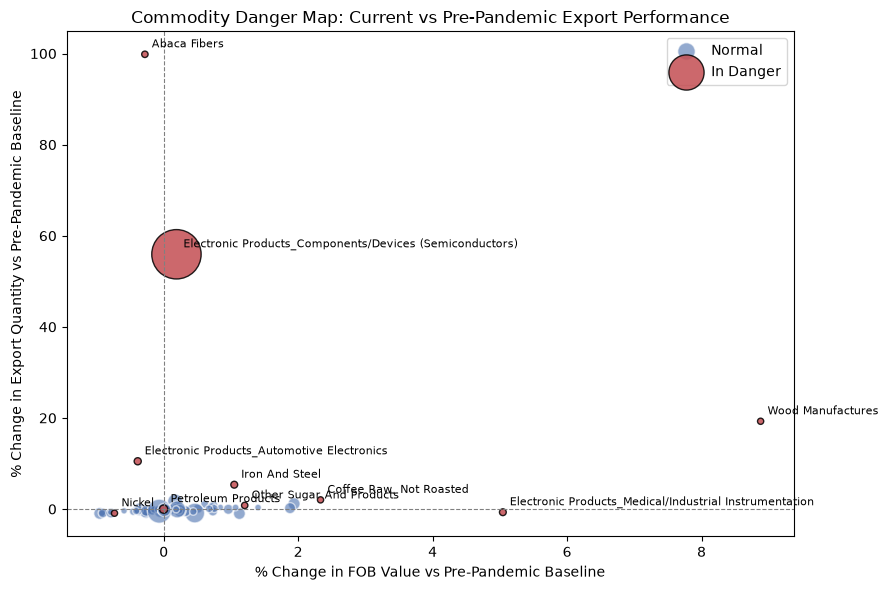

In [ ]:
# ---- 4. VISUALIZE: scatter map -------------------------------------------
normal = result[~result["in_danger"]]
danger = result[result["in_danger"]]

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(
    normal["pct_change_fob"], normal["pct_change_qty"],
    s=normal["baseline_fob_share"] * 3000 + 20,
    c="#4C72B0", alpha=0.6, label="Normal", edgecolor="white",
)
ax.scatter(
    danger["pct_change_fob"], danger["pct_change_qty"],
    s=danger["baseline_fob_share"] * 3000 + 20,
    c="#C44E52", alpha=0.85, label="In Danger", edgecolor="black",
)
for _, row in danger.iterrows():
    ax.annotate(
        row["Commodity"], (row["pct_change_fob"], row["pct_change_qty"]),
        fontsize=8, xytext=(5, 5), textcoords="offset points",
    )
ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
ax.axvline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set_xlabel("% Change in FOB Value vs Pre-Pandemic Baseline")
ax.set_ylabel("% Change in Export Quantity vs Pre-Pandemic Baseline")
ax.set_title("Commodity Danger Map: Current vs Pre-Pandemic Export Performance")
ax.legend()
plt.tight_layout()
plt.show()

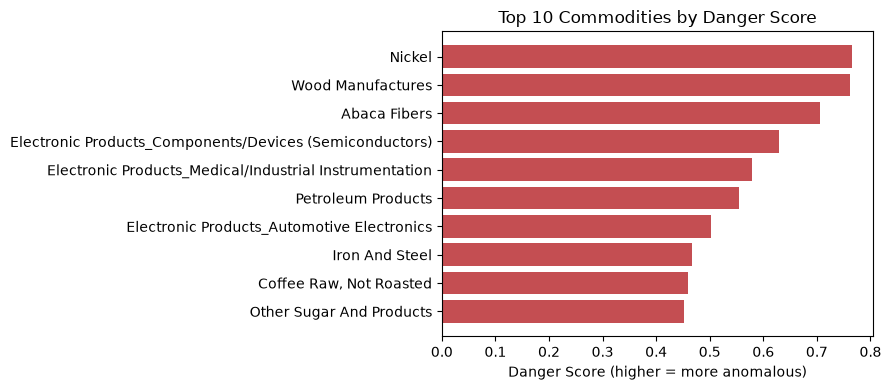

In [ ]:
# ---- 4b. VISUALIZE: ranking bar chart -------------------------------------
top = result.head(TOP_N).sort_values("danger_score")

fig, ax = plt.subplots(figsize=(9, max(4, 0.4 * TOP_N)))
colors = ["#C44E52" if d else "#4C72B0" for d in top["in_danger"]]
ax.barh(top["Commodity"], top["danger_score"], color=colors)
ax.set_xlabel("Danger Score (higher = more anomalous)")
ax.set_title(f"Top {TOP_N} Commodities by Danger Score")
plt.tight_layout()
plt.show()

Core Commodity Dominance & Crisis Risk Exposure

In [31]:
#EDA (Joel)

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler


df = pd.read_csv('combined.csv')

 
print(df.info())


print("\nMissing Values:")
print(df.isnull().sum())


print("\nDescriptive Stats (Outlier Inspection):")
print(df[['Quantity', 'FOB']].describe())

<class 'pandas.DataFrame'>
RangeIndex: 30444 entries, 0 to 30443
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Commodity               30444 non-null  str    
 1   Country Of Destination  30444 non-null  str    
 2   Year                    30444 non-null  int64  
 3   Quantity                30444 non-null  float64
 4   FOB                     30444 non-null  float64
 5   source_file             30444 non-null  str    
dtypes: float64(2), int64(1), str(3)
memory usage: 1.4 MB
None

Missing Values:
Commodity                 0
Country Of Destination    0
Year                      0
Quantity                  0
FOB                       0
source_file               0
dtype: int64

Descriptive Stats (Outlier Inspection):
           Quantity           FOB
count  3.044400e+04  3.044400e+04
mean   1.932629e+07  1.941538e+07
std    6.909233e+08  1.894973e+08
min    0.000000e+00  2.500000e+01
25%    

In [32]:
#PreProcessing
# 1. Feature Engineering: HHI Calculation
# Measuring market concentration using the Herfindahl-Hirschman Index (HHI)
commodity_fob_totals = df.groupby('Commodity')['FOB'].transform('sum')
df['Market_Share'] = (df['FOB'] / commodity_fob_totals) * 100
df['Share_Squared'] = df['Market_Share'] ** 2
hhi_df = df.groupby('Commodity')['Share_Squared'].sum().reset_index().rename(columns={'Share_Squared': 'HHI_Score'})

# 2. Aggregation (Creating the Master Commodity Dataset)
agg_df = df.groupby('Commodity').agg(
    Total_Quantity=('Quantity', 'sum'),
    Total_FOB=('FOB', 'sum'),
    Export_Frequency=('Commodity', 'count')
).reset_index()

final_df = pd.merge(hhi_df, agg_df, on='Commodity')

# 3. Outlier Treatment (95th Percentile Capping)
# Prevents extreme shipments from skewing cluster centers
for col in ['Total_Quantity', 'Total_FOB', 'Export_Frequency']:
    cap = final_df[col].quantile(0.95)
    final_df[col] = np.where(final_df[col] > cap, cap, final_df[col])

# 4. Feature Scaling
# Normalizing values for distance-based ML models
scaler = StandardScaler()
features = ['HHI_Score', 'Total_Quantity', 'Total_FOB', 'Export_Frequency']
scaled_cols = ['Scaled_HHI', 'Scaled_Quantity', 'Scaled_FOB', 'Scaled_Frequency']
final_df[scaled_cols] = scaler.fit_transform(final_df[features])

# Save output for model ingestion
final_df.to_csv('preprocessed_commodities.csv', index=False)
print("\nPreprocessing complete. Data saved as 'preprocessed_commodities.csv'.")


Preprocessing complete. Data saved as 'preprocessed_commodities.csv'.


In [33]:
#Machine learning (K-Means, Hierarchical Clustering and Random Forest Classifier)

import pandas as pd
import numpy as np
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

df = pd.read_csv('preprocessed_commodities.csv')

#K-MEANS (High Market Concentration)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Concentration_Cluster'] = kmeans.fit_predict(df[['Scaled_HHI', 'Scaled_FOB']])

#HIERARCHICAL CLUSTERING (Core Commodity Dominance)
hc_model = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
df['Dominance_Cluster'] = hc_model.fit_predict(df[['Scaled_Quantity', 'Scaled_FOB', 'Scaled_Frequency']])

#TASK 3: RANDOM FOREST (Crisis Risk Exposure)
#Re-calculate the 2019-2020 Pandemic Drop target
raw_df = pd.read_csv('combined.csv')
yearly_vol = raw_df.groupby(['Commodity', 'Year'])['Quantity'].sum().reset_index()
pivot_vol = yearly_vol.pivot(index='Commodity', columns='Year', values='Quantity').fillna(0)
pivot_vol['Risk_Target'] = ((pivot_vol[2020] - pivot_vol[2019]) / pivot_vol[2019].replace(0, np.nan) <= -0.15).astype(int)

#Merge target into the master dataset
ml_df = pd.merge(df, pivot_vol[['Risk_Target']], on='Commodity')

#Split and train the classifier
X = ml_df[['Scaled_HHI', 'Scaled_Quantity', 'Scaled_FOB', 'Scaled_Frequency']]
y = ml_df['Risk_Target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

print("--- MODEL TRAINING COMPLETE ---")
print(classification_report(y_test, rf.predict(X_test)))

--- MODEL TRAINING COMPLETE ---
              precision    recall  f1-score   support

           0       0.57      0.44      0.50         9
           1       0.38      0.50      0.43         6

    accuracy                           0.47        15
   macro avg       0.47      0.47      0.46        15
weighted avg       0.49      0.47      0.47        15



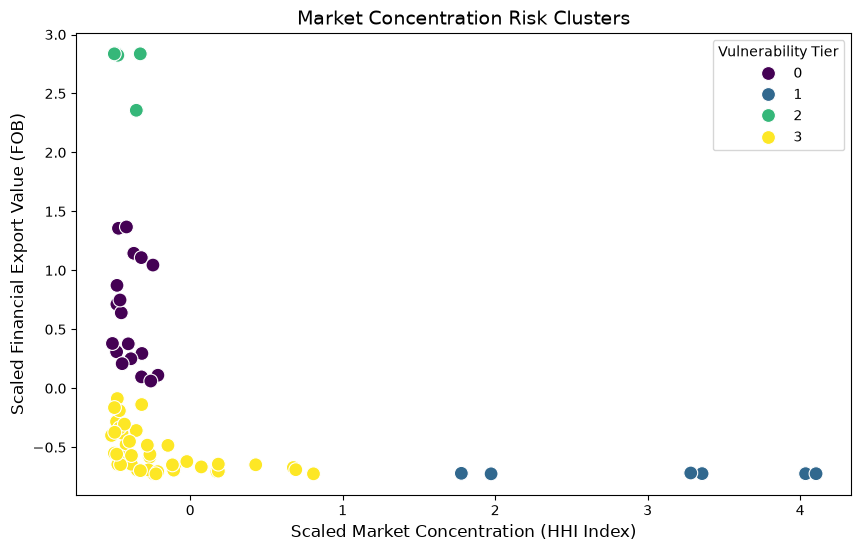

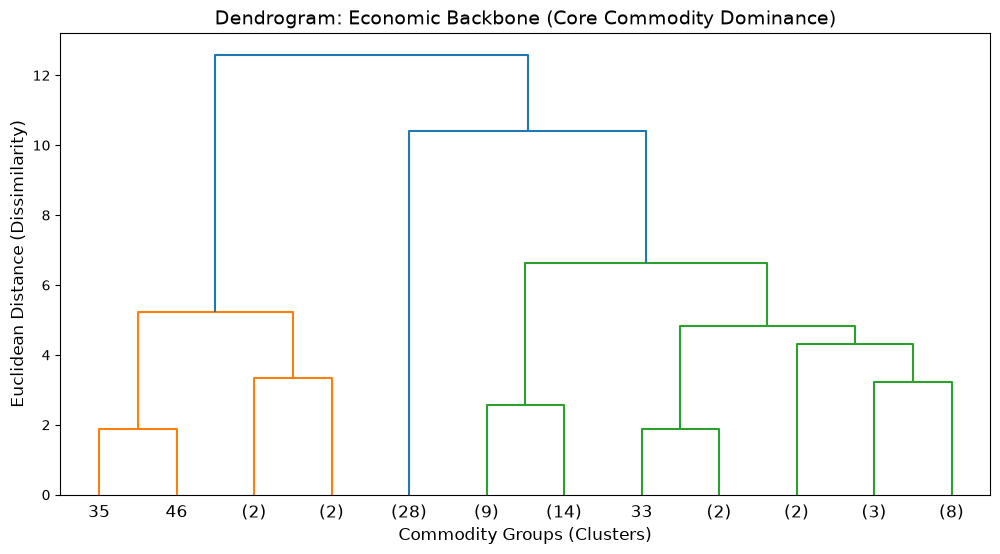

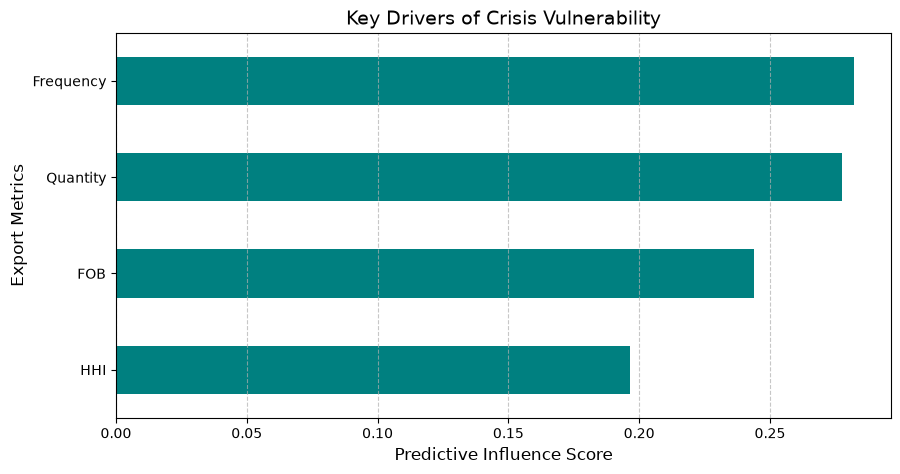

In [34]:
#visual
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.cluster.hierarchy as sch

#K-MEANS SCATTERPLOT
plt.figure(figsize=(10, 6))
scatter = sns.scatterplot(
    data=df, 
    x='Scaled_HHI', 
    y='Scaled_FOB', 
    hue='Concentration_Cluster', 
    palette='viridis', 
    s=100
)
plt.title('Market Concentration Risk Clusters', fontsize=14)
plt.xlabel('Scaled Market Concentration (HHI Index)', fontsize=12)
plt.ylabel('Scaled Financial Export Value (FOB)', fontsize=12)
plt.legend(title='Vulnerability Tier')
plt.show()

#HIERARCHICAL CLUSTERING DENDROGRAM
plt.figure(figsize=(12, 6))
linkage_matrix = sch.linkage(df[['Scaled_Quantity', 'Scaled_FOB', 'Scaled_Frequency']], method='ward')
sch.dendrogram(linkage_matrix, truncate_mode='lastp', p=12) 
plt.title('Dendrogram: Economic Backbone (Core Commodity Dominance)', fontsize=14)
plt.xlabel('Commodity Groups (Clusters)', fontsize=12)
plt.ylabel('Euclidean Distance (Dissimilarity)', fontsize=12)
plt.show()

#RANDOM FOREST FEATURE IMPORTANCE
plt.figure(figsize=(10, 5))
feature_names = ['HHI', 'Quantity', 'FOB', 'Frequency']
importances = pd.Series(rf.feature_importances_, index=feature_names)
importances.sort_values().plot(kind='barh', color='teal')
plt.title('Key Drivers of Crisis Vulnerability', fontsize=14)
plt.xlabel('Predictive Influence Score', fontsize=12)
plt.ylabel('Export Metrics', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

##### 3. Shifts & Predictions



Price Elasticity and Demand Forecasting

In [35]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, r2_score

# 1. LOAD DATA & INITIAL CLEANING
df = pd.read_csv('combined.csv')

# Sort strictly by the 'Year' column to maintain chronological order
df = df.sort_values('Year').reset_index(drop=True)

# 2. FEATURE ENGINEERING & ECONOMIC TRANSFORMS
# Calculate unit price: Free On Board (FOB) value divided by Quantity
df['unit_price'] = df['FOB'] / df['Quantity']

# Handle cases where quantity or price might be zero to avoid log(0) errors
df = df[(df['Quantity'] > 0) & (df['unit_price'] > 0)].reset_index(drop=True)

# Economic log transformations for Elasticity
df['log_price'] = np.log(df['unit_price'])
df['log_demand'] = np.log(df['Quantity'])

# Convert string/object columns into category types for LightGBM
df['Commodity'] = df['Commodity'].astype('category')
df['Country Of Destination'] = df['Country Of Destination'].astype('category')

# Define feature matrix and target
# Included 'Year' as your explicit temporal feature
features = ['log_price', 'Year', 'Commodity', 'Country Of Destination']
X = df[features]
y = df['log_demand']

# 3. STRICT CHRONOLOGICAL TRAIN/TEST SPLIT
# 80/20 train/test split based entirely on time sequence to avoid data leakage
split_idx = int(len(df) * 0.8)

X_train, y_train = X.iloc[:split_idx], y.iloc[:split_idx]
X_test, y_test = X.iloc[split_idx:], y.iloc[split_idx:]

print(f"Dataset Split Boundaries:")
print(f"↳ Training data period: Year {df['Year'].iloc[0]} to Year {df['Year'].iloc[split_idx-1]} ({len(X_train)} rows)")
print(f"↳ Testing data period:  Year {df['Year'].iloc[split_idx]} to Year {df['Year'].iloc[-1]} ({len(X_test)} rows)\n")

# 4. MONOTONIC CONSTRAINTS & MODEL DEFINITION
# Enforce that an increase in 'log_price' (-1) results in a downward shift in demand.
# 0 means no constraint for Year, Commodity, and Country Of Destination.
monotonic_constraints = [-1, 0, 0, 0]

model = lgb.LGBMRegressor(
    n_estimators=200,
    learning_rate=0.03,
    max_depth=6,
    num_leaves=31,
    monotonically_constrained_features=monotonic_constraints,
    random_state=42
)

# 5. TRAINING
# Train the model with early stopping on the chronological test window
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False)]
)

# 6. EVALUATION
y_pred_log = model.predict(X_test)

# Convert predictions back from log space to normal units (Actual Quantities)
y_test_actual = np.exp(y_test)
y_pred_actual = np.exp(y_pred_log)

r2 = r2_score(y_test_actual, y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))

print("--- Model Performance On Out-Of-Sample Future Test Window ---")
print(f"R² Score: {r2:.4f}")
print(f"RMSE (Quantity Units): {rmse:.2f}")

# Feature Importance Check
importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n--- Feature Importance ---")
print(importance.to_string(index=False))

Dataset Split Boundaries:
↳ Training data period: Year 2018 to Year 2024 (24348 rows)
↳ Testing data period:  Year 2024 to Year 2025 (6087 rows)

[LightGBM] [Warning] Unknown parameter: monotonically_constrained_features
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Unknown parameter: monotonically_constrained_features
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000663 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 563
[LightGBM] [Info] Number of data points in the train set: 24348, number of used features: 4
[LightGBM] [Warning] Unknown parameter: monotonically_constrained_features
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 9.378739
[LightGBM] [Warning] No further splits with positive gain, best g

[LightGBM] [Warning] Unknown parameter: monotonically_constrained_features
[LightGBM] [Warning] Unknown parameter: monotonically_constrained_features
[LightGBM] [Warning] Unknown parameter: monotonically_constrained_features
[LightGBM] [Warning] Unknown parameter: monotonically_constrained_features
[LightGBM] [Warning] Unknown parameter: monotonically_constrained_features
[LightGBM] [Warning] Unknown parameter: monotonically_constrained_features
[LightGBM] [Warning] Unknown parameter: monotonically_constrained_features
[LightGBM] [Warning] Unknown parameter: monotonically_constrained_features
[LightGBM] [Warning] Unknown parameter: monotonically_constrained_features
[LightGBM] [Warning] Unknown parameter: monotonically_constrained_features
[LightGBM] [Warning] Unknown parameter: monotonically_constrained_features
[LightGBM] [Warning] Unknown parameter: monotonically_constrained_features
[LightGBM] [Warning] Unknown parameter: monotonically_constrained_features
[LightGBM] [Warning] Unkn

C:\Users\yvett\AppData\Local\Temp\ipykernel_13320\1241653462.py:39: UserWarning: Glyph 10132 (\N{HEAVY WIDE-HEADED RIGHTWARDS ARROW}) missing from font(s) Arial.
  plt.tight_layout()
c:\myPrograms\DataSci\IPYNB\DataSci1-Group9-Act2\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10132 (\N{HEAVY WIDE-HEADED RIGHTWARDS ARROW}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


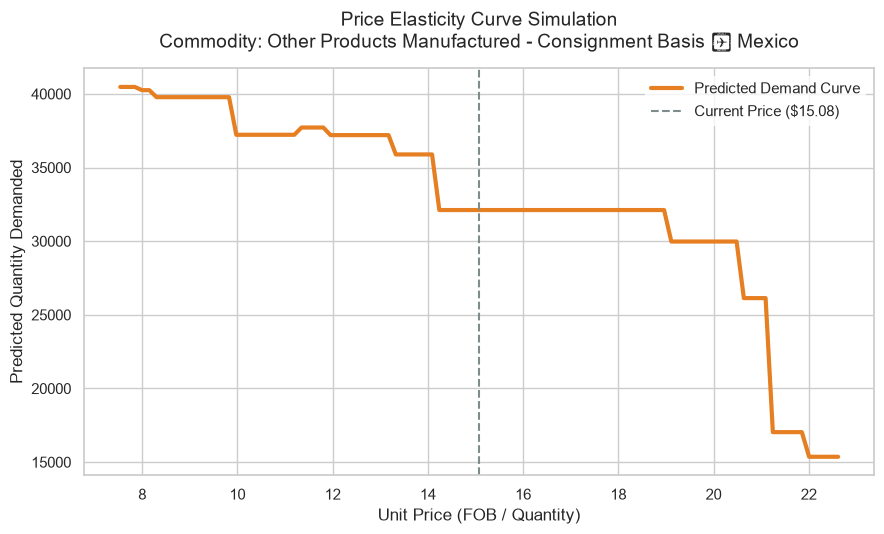

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Choose a representative row from your test set to simulate
# (e.g., index 0, or change this to inspect different commodities)
sample_idx = 0 
base_scenario = X_test.iloc[[sample_idx]].copy()

# 2. Extract original values for labels
original_log_price = base_scenario['log_price'].values[0]
original_price = np.exp(original_log_price)
commodity_name = base_scenario['Commodity'].values[0]
country_name = base_scenario['Country Of Destination'].values[0]

# 3. Create a range of prices (from 50% to 150% of the original unit price)
price_range = np.linspace(original_price * 0.5, original_price * 1.5, 100)
log_price_range = np.log(price_range)

# 4. Predict demand across the price spectrum
predicted_demands = []
for lp in log_price_range:
    scenario = base_scenario.copy()
    scenario['log_price'] = lp
    pred_log_demand = model.predict(scenario)
    predicted_demands.append(np.exp(pred_log_demand)[0])

# 5. Plot the Elasticity Curve
plt.figure(figsize=(9, 5.5))
sns.set_theme(style="whitegrid")

plt.plot(price_range, predicted_demands, color='#e67e22', linewidth=3, label='Predicted Demand Curve')
plt.axvline(original_price, color='#7f8c8d', linestyle='--', linewidth=1.5, 
            label=f'Current Price (${original_price:.2f})')

plt.title(f'Price Elasticity Curve Simulation\nCommodity: {commodity_name} ➔ {country_name}', fontsize=14, pad=15)
plt.xlabel('Unit Price (FOB / Quantity)', fontsize=12)
plt.ylabel('Predicted Quantity Demanded', fontsize=12)
plt.legend(frameon=True, facecolor='white', edgecolor='none')
plt.tight_layout()
plt.show()